# Chapter 6 — The Randomized Spatial Prisoner's Dilemma
**Modeling Social Behavior** | Smaldino

---

## What This Model Does

This notebook extends the simple spatial cooperation model (Exercise 1) with one new mechanism: **probabilistic randomization** of agent locations.

Before each game-play stage, every agent has a small probability of swapping positions with a randomly chosen other agent anywhere on the grid. This disrupts the spatial clusters that protected cooperators in the previous model.

**The central question:** How much network disruption can cooperation tolerate before it collapses?

---

## What Changed From Exercise 1

| Component | Exercise 1 (PD_simple) | Exercise 2 (PD_randomized) |
|---|---|---|
| Grid & strategies | L×L grid, ALLC vs ALLD | Same |
| Payoff rules | b, c parameters | Same |
| Evolution | Copy best neighbor | Same |
| **NEW: Randomization** | — | Each agent swaps position with probability `randomization_prob` before playing |

Everything else is identical. The only new global parameter is `randomization_prob`.

---

## Variable Types

- **Global variables** — `b`, `c`, `L`, `init_coop_freq`, `randomization_prob`
- **Agent variables** — `strategy`, `payoff`
- **Local variables** — temporary values inside functions (swap targets, indices, etc.)


## Step 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

np.random.seed(42)


## Step 2 — Global Parameters

All parameters from Exercise 1 carry over. The only addition is `randomization_prob`.

**`randomization_prob`** — the probability that any given agent swaps its grid position
with a randomly chosen other agent at the start of each time step.

- When `randomization_prob = 0.0`: no movement — identical to Exercise 1
- When `randomization_prob = 1.0`: every agent swaps every step — complete random mixing
- Intermediate values: partial disruption of spatial assortment

> **Smaldino's finding (Figure 6.6):** Even values around 0.04–0.08 are enough to
> substantially reduce cooperation. Past ~0.10, cooperation cannot be maintained at all.


In [2]:
# ── GLOBAL VARIABLES ─────────────────────────────────────────────────────

L                  = 31     # Grid side length → 31×31 = 961 agents
b                  = 1.0    # Benefit conferred on partner by cooperating
c                  = 0.20   # Cost paid by cooperator per interaction
                            # Kept below b/4 = 0.25 so cooperation can survive
                            # when randomization_prob is low
init_coop_freq     = 0.5    # Starting proportion of cooperators

# ── NEW GLOBAL VARIABLE ───────────────────────────────────────────────────
randomization_prob = 0.0    # Probability each agent swaps location each step
                            # Try: 0.02, 0.05, 0.08, 0.10

N = L * L
print(f"Grid: {L}×{L} = {N} agents")
print(f"b={b}, c={c}  |  threshold b/4 = {b/4}")
print(f"randomization_prob = {randomization_prob}")


Grid: 31×31 = 961 agents
b=1.0, c=0.2  |  threshold b/4 = 0.25
randomization_prob = 0.0


## Step 3 — Reused Functions From Exercise 1

`initialize_grid`, `get_neighbors`, `play_game`, and `evolve` are unchanged.
They are reproduced here in full so this notebook is self-contained.


In [3]:
# ── REUSED FROM EXERCISE 1 (unchanged) ───────────────────────────────────

def initialize_grid(L, init_coop_freq, seed=None):
    """
    Create the starting population.
    Each cell gets strategy=1 (cooperator) with probability init_coop_freq,
    otherwise strategy=0 (defector). All payoffs start at zero.

    Parameters
    ----------
    L : int                  — global, grid side length
    init_coop_freq : float   — global, starting cooperator proportion
    seed : int or None       — optional reproducibility seed

    Returns
    -------
    strategy : np.ndarray (L, L) int    — agent variable
    payoff   : np.ndarray (L, L) float  — agent variable, all zeros
    """
    if seed is not None:
        np.random.seed(seed)
    strategy = (np.random.random((L, L)) < init_coop_freq).astype(int)
    payoff   = np.zeros((L, L), dtype=float)
    return strategy, payoff


def get_neighbors(grid):
    """
    Return the four von Neumann neighbors for every cell simultaneously
    using np.roll() with toroidal (wrap-around) boundaries.

    Parameters
    ----------
    grid : np.ndarray (L, L) — any per-agent array

    Returns
    -------
    list of 4 arrays [north, south, east, west], each shape (L, L)
    (local variables: each shifted array exists only inside this function)
    """
    north = np.roll(grid, -1, axis=0)
    south = np.roll(grid,  1, axis=0)
    east  = np.roll(grid, -1, axis=1)
    west  = np.roll(grid,  1, axis=1)
    return [north, south, east, west]


def play_game(strategy, b, c):
    """
    Each agent plays the PD with its 4 neighbors and accumulates payoff.

    Cooperator payoff = n_C*(b-c) - n_D*c
    Defector payoff   = n_C*b

    Parameters
    ----------
    strategy : np.ndarray (L, L) — agent variable
    b, c     : float             — global variables

    Returns
    -------
    payoff : np.ndarray (L, L) float — agent variable

    Local variables: neighbors, n_C, n_D, coop_mask, defect_mask
    """
    neighbors   = get_neighbors(strategy)
    n_C         = sum(neighbors)
    n_D         = 4 - n_C
    payoff      = np.zeros_like(strategy, dtype=float)
    coop_mask   = (strategy == 1)
    defect_mask = (strategy == 0)
    payoff[coop_mask]   = n_C[coop_mask]   * (b - c) - n_D[coop_mask]   * c
    payoff[defect_mask] = n_C[defect_mask] * b
    return payoff


def evolve(strategy, payoff):
    """
    Each agent copies the strategy of its highest-payoff neighbor,
    but only if that neighbor's payoff exceeds its own.
    All updates happen simultaneously.

    Parameters
    ----------
    strategy, payoff : np.ndarray (L, L) — agent variables

    Returns
    -------
    new_strategy : np.ndarray (L, L) int — agent variable

    Local variables: stacked_payoffs, stacked_strategies, best_neighbor_payoff,
                     best_neighbor_idx, best_neighbor_strategy, imitate_mask, rows, cols
    """
    stacked_payoffs    = np.stack(get_neighbors(payoff),    axis=0)
    stacked_strategies = np.stack(get_neighbors(strategy),  axis=0)
    best_neighbor_payoff  = stacked_payoffs.max(axis=0)
    best_neighbor_idx     = stacked_payoffs.argmax(axis=0)
    rows = np.arange(strategy.shape[0])[:, None]
    cols = np.arange(strategy.shape[1])[None, :]
    best_neighbor_strategy = stacked_strategies[best_neighbor_idx, rows, cols]
    imitate_mask = best_neighbor_payoff > payoff
    new_strategy = strategy.copy()
    new_strategy[imitate_mask] = best_neighbor_strategy[imitate_mask]
    return new_strategy


print("All Exercise 1 functions loaded.")


All Exercise 1 functions loaded.


## Step 4 — The New Function: `randomize_locations`

This is the only new function in the model. It runs **before** `play_game` each time step.

**What it does:** Each agent independently draws a random number. If that number is below
`randomization_prob`, the agent swaps its grid position with a randomly chosen other agent.

**Implementation note:** We implement this as a swap of the *strategy values* in the array,
rather than actually moving agents — the result is identical, and it's much simpler in Python.
We randomly select a subset of cells to be "movers", then for each mover we pick a random
target cell anywhere on the grid and swap the strategy values between the two cells.

> **Why this works:** The grid positions are fixed — what changes is which strategy sits in
> each position. Swapping strategy values between two cells is equivalent to two agents
> swapping their physical locations.


In [4]:
# ── NEW FUNCTION: RANDOMIZE LOCATIONS ────────────────────────────────────

def randomize_locations(strategy, randomization_prob):
    """
    Before game play, each agent independently has a chance to swap its
    grid position (strategy value) with a randomly chosen other agent.

    This disrupts spatial assortment by mixing cooperators and defectors.
    When randomization_prob = 0, the grid is unchanged.
    When randomization_prob = 1, positions are heavily shuffled each step.

    Parameters
    ----------
    strategy           : np.ndarray (L, L) int — agent variable
    randomization_prob : float               — global variable, swap probability [0, 1]

    Returns
    -------
    new_strategy : np.ndarray (L, L) int — agent variable, strategies after swapping

    Local variables
    ---------------
    new_strategy   : copy of strategy array modified in place
    swap_mask      : boolean array (L, L) — True where an agent will swap
    mover_rows     : row indices of swapping agents
    mover_cols     : col indices of swapping agents
    n_movers       : number of swapping agents this step
    target_flat    : flat (1D) indices of randomly chosen swap targets
    target_rows    : row indices of swap targets
    target_cols    : col indices of swap targets
    temp           : temporary storage of strategy value during swap
    """
    new_strategy = strategy.copy()

    # Each cell independently decides to swap with probability randomization_prob
    swap_mask  = np.random.random((L, L)) < randomization_prob  # local: bool (L, L)
    mover_rows, mover_cols = np.where(swap_mask)                # local: 1D index arrays
    n_movers = len(mover_rows)                                   # local: int

    if n_movers == 0:
        return new_strategy  # nothing to do

    # For each mover, pick a random target cell anywhere on the grid (flat index 0 to N-1)
    target_flat = np.random.randint(0, L * L, size=n_movers)    # local: 1D array
    target_rows = target_flat // L                               # local: row of each target
    target_cols = target_flat  % L                               # local: col of each target

    # Perform the swaps sequentially
    for i in range(n_movers):
        r1, c1 = mover_rows[i], mover_cols[i]   # local: mover position
        r2, c2 = target_rows[i], target_cols[i] # local: target position
        temp = new_strategy[r1, c1]              # local: hold value during swap
        new_strategy[r1, c1] = new_strategy[r2, c2]
        new_strategy[r2, c2] = temp

    return new_strategy


# Quick sanity checks
strategy_test, _ = initialize_grid(L, 0.5, seed=42)
after_zero = randomize_locations(strategy_test, 0.0)
print("prob=0.0 → grid unchanged:            ", np.array_equal(strategy_test, after_zero))

after_full = randomize_locations(strategy_test, 1.0)
print("prob=1.0 → grid shuffled:             ", not np.array_equal(strategy_test, after_full))
print(f"  Cooperator freq before: {strategy_test.mean():.3f} | after: {after_full.mean():.3f}",
      " (frequency is preserved)")


prob=0.0 → grid unchanged:             True
prob=1.0 → grid shuffled:              True
  Cooperator freq before: 0.501 | after: 0.501  (frequency is preserved)


## Step 5 — Updated Time Step and Simulation

The only change to `step()` vs Exercise 1: `randomize_locations()` is called **first**,
before `play_game`. Order: `randomize → play game → evolve`.

The simulation runner now also always saves the **final grid state**, regardless of
whether the simulation stopped early. This avoids a subtle bug: if the model stops early
(one strategy wins), a snapshot requested for a later time step would never be created.


In [5]:
# ── UPDATED STEP FUNCTION ────────────────────────────────────────────────

def step(strategy, b, c, randomization_prob):
    """
    Advance the model by one time step.
    Order: (1) randomize locations → (2) play game → (3) evolve

    Parameters
    ----------
    strategy           : np.ndarray (L, L) — agent variable
    b, c               : float             — global variables
    randomization_prob : float             — global variable

    Returns
    -------
    new_strategy : np.ndarray (L, L) — updated strategies
    coop_freq    : float             — cooperator frequency after this step
    """
    strategy     = randomize_locations(strategy, randomization_prob)  # Stage 0 (NEW)
    payoff       = play_game(strategy, b, c)                          # Stage 1
    new_strategy = evolve(strategy, payoff)                           # Stage 2
    return new_strategy, new_strategy.mean()


# ── SIMULATION RUNNER ────────────────────────────────────────────────────

def run_simulation(L, b, c, init_coop_freq, randomization_prob,
                   n_steps=200, seed=42, save_final_grid=False):
    """
    Run the full model for n_steps time steps and record results.

    Parameters
    ----------
    L, b, c, init_coop_freq, randomization_prob : global variables
    n_steps         : int  — number of time steps to run
    seed            : int  — random seed
    save_final_grid : bool — if True, also return the final grid state

    Returns
    -------
    history      : list of float   — cooperator frequency at each time step
    final_grid   : np.ndarray or None — final strategy grid (if save_final_grid=True)
    """
    strategy, _ = initialize_grid(L, init_coop_freq, seed=seed)
    history     = [strategy.mean()]

    for t in range(1, n_steps + 1):
        strategy, coop_freq = step(strategy, b, c, randomization_prob)
        history.append(coop_freq)

        # Early stop: one strategy has completely taken over
        if coop_freq == 0.0 or coop_freq == 1.0:
            history += [coop_freq] * (n_steps - t)  # pad to full length
            break

    if save_final_grid:
        return history, strategy.copy()
    return history, None


print("Step and simulation functions ready.")


Step and simulation functions ready.


## Step 6 — Visualization Helper

In [6]:
def plot_grid(strategy, ax=None, title=None):
    """Display the grid. Blue = cooperator, Red = defector."""
    cmap = mcolors.ListedColormap(['#e63946', '#457b9d'])
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(strategy, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=10)


## Step 7 — Baseline Check: Zero Randomization

First confirm this model produces the same result as Exercise 1 when `randomization_prob = 0`.
If nothing is broken, cooperation should dominate.


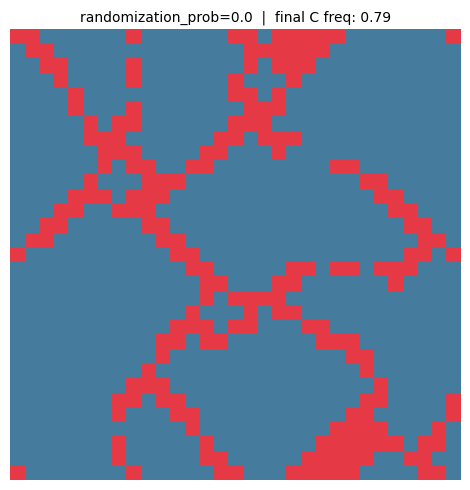

Final cooperator frequency (prob=0.0): 0.791
Expected: cooperation dominates (~0.80+) — same as Exercise 1


In [7]:
# ── SANITY CHECK: prob=0 should match Exercise 1 ─────────────────────────

hist_zero, grid_zero = run_simulation(
    L, b, c, init_coop_freq,
    randomization_prob=0.0,
    n_steps=50, seed=42, save_final_grid=True
)

fig, ax = plt.subplots(figsize=(5, 5))
plot_grid(grid_zero, ax=ax,
          title=f"randomization_prob=0.0  |  final C freq: {hist_zero[-1]:.2f}")
plt.tight_layout()
plt.show()

print(f"Final cooperator frequency (prob=0.0): {hist_zero[-1]:.3f}")
print("Expected: cooperation dominates (~0.80+) — same as Exercise 1")


## Step 8 — What Disruption Looks Like Spatially

Compare the equilibrium grid for three randomization levels side by side.
This recreates the spirit of Figure 6.7 from the book.

Notice how clusters that were clean and well-defined at `prob=0` become increasingly
fragmented, until at high randomization no cluster structure remains at all.


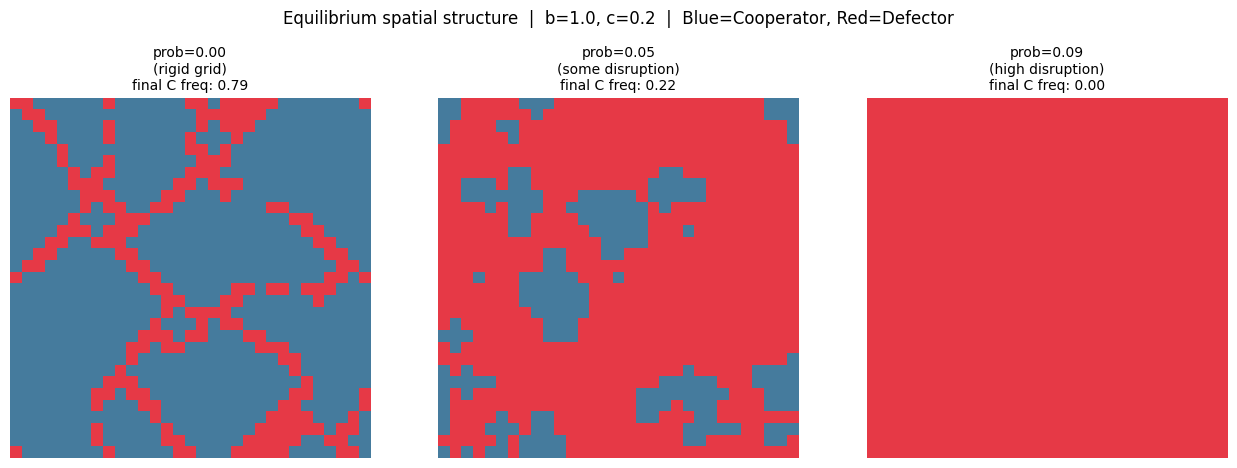

In [8]:
# ── SPATIAL COMPARISON ACROSS RANDOMIZATION LEVELS ───────────────────────

rand_levels = [0.0, 0.05, 0.09]
labels      = ['prob=0.00\n(rigid grid)', 'prob=0.05\n(some disruption)',
               'prob=0.09\n(high disruption)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, r_prob, label in zip(axes, rand_levels, labels):
    hist, final_grid = run_simulation(
        L, b, c, init_coop_freq,
        randomization_prob=r_prob,
        n_steps=200, seed=42, save_final_grid=True
    )
    plot_grid(final_grid, ax=ax,
              title=f"{label}\nfinal C freq: {hist[-1]:.2f}")

fig.suptitle(f"Equilibrium spatial structure  |  b={b}, c={c}  "
             f"|  Blue=Cooperator, Red=Defector",
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


## Step 9 — Cooperator Frequency Over Time Across Randomization Levels

Plot how cooperation evolves over 200 time steps for several values of `randomization_prob`.
Notice how increasing disruption first lowers the equilibrium level, then causes collapse.


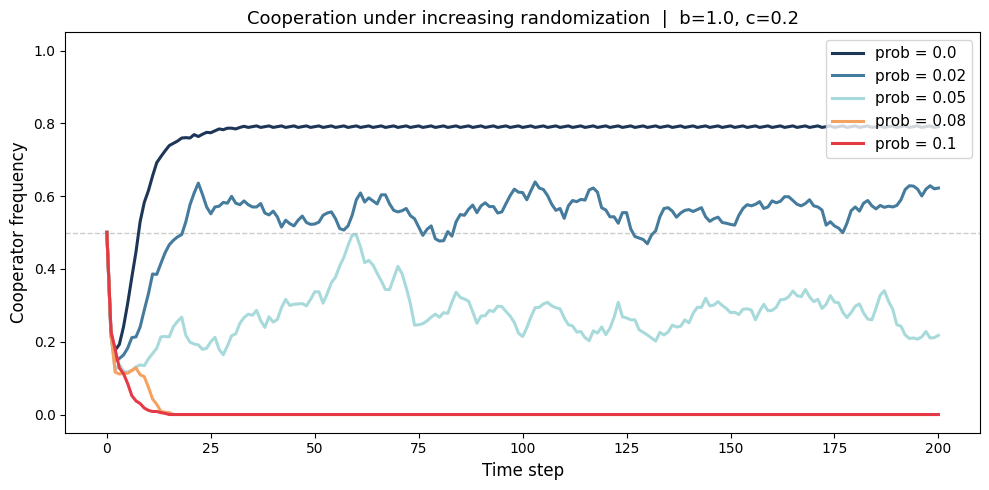

In [9]:
# ── FREQUENCY TRAJECTORIES ───────────────────────────────────────────────

r_probs = [0.0, 0.02, 0.05, 0.08, 0.10]
colors  = ['#1d3557', '#457b9d', '#a8dadc', '#f4a261', '#e63946']

fig, ax = plt.subplots(figsize=(10, 5))

for r_prob, color in zip(r_probs, colors):
    hist, _ = run_simulation(
        L, b, c, init_coop_freq,
        randomization_prob=r_prob,
        n_steps=200, seed=42
    )
    ax.plot(hist, color=color, linewidth=2.2, label=f'prob = {r_prob}')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.4)
ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("Cooperator frequency", fontsize=12)
ax.set_title(f"Cooperation under increasing randomization  |  b={b}, c={c}", fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


## Step 10 — Recreating Figure 6.6: Equilibrium Cooperation vs Randomization

Sweep `randomization_prob` from 0 to 0.10 and record the equilibrium cooperator frequency
across 20 runs per value. This directly recreates Figure 6.6 from the book.

> ⚠️ **This cell takes a few minutes** — it runs many simulations.


Running 21 × 20 = 420 simulations...
Done.


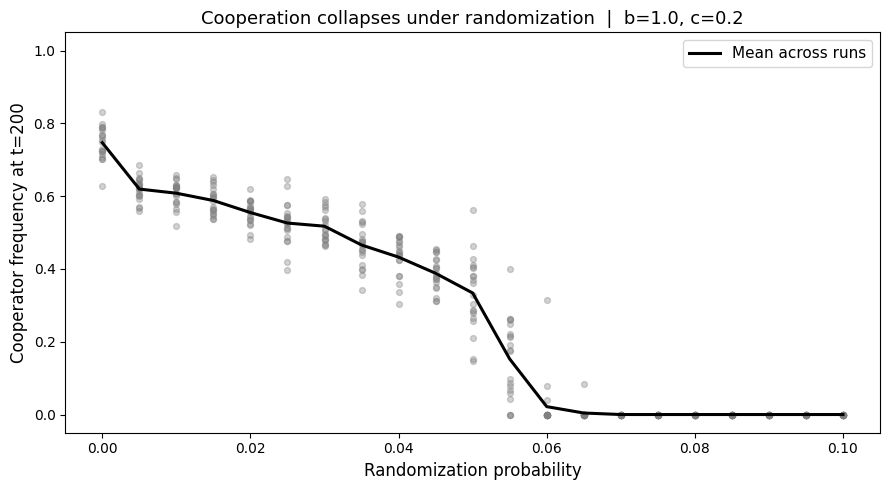

In [10]:
# ── FIGURE 6.6 RECREATION ────────────────────────────────────────────────

r_values      = np.arange(0.0, 0.105, 0.005)
n_runs        = 20
n_steps_sweep = 200

results = np.zeros((len(r_values), n_runs))

print(f"Running {len(r_values)} × {n_runs} = {len(r_values)*n_runs} simulations...")

for i, r_prob in enumerate(r_values):
    for run in range(n_runs):
        hist, _ = run_simulation(
            L, b, c, init_coop_freq,
            randomization_prob=r_prob,
            n_steps=n_steps_sweep,
            seed=run * 200 + i
        )
        results[i, run] = hist[-1]

print("Done.")

fig, ax = plt.subplots(figsize=(9, 5))

for run in range(n_runs):
    ax.scatter(r_values, results[:, run],
               color='gray', alpha=0.35, s=18, zorder=2)

ax.plot(r_values, results.mean(axis=1),
        color='black', linewidth=2.2, zorder=3, label='Mean across runs')

ax.set_xlabel("Randomization probability", fontsize=12)
ax.set_ylabel(f"Cooperator frequency at t={n_steps_sweep}", fontsize=12)
ax.set_title(f"Cooperation collapses under randomization  |  b={b}, c={c}", fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## Step 11 — 2D Sweep: Cost × Randomization (Heatmap)

In Exercise 1, the phase transition depended only on `c`. Now we have two parameters.
This heatmap shows how cooperation depends jointly on both `c` and `randomization_prob`.

The golden dashed line marks `c = b/4` — the Exercise 1 threshold.

> ⚠️ **This cell is slow.** Reduce `n_runs` to 3 to speed it up.


Running 180 simulations...
Done.


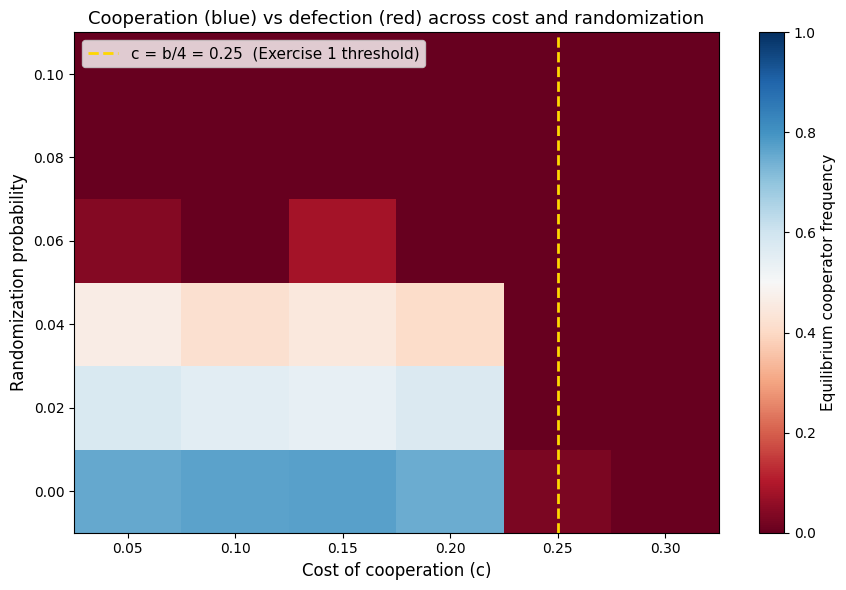

Blue = cooperation thrives | Red = defection dominates


In [11]:
# ── 2D SWEEP: COST × RANDOMIZATION ───────────────────────────────────────

c_sweep    = np.arange(0.05, 0.35, 0.05)    # 6 cost values
r_sweep    = np.arange(0.00, 0.12, 0.02)    # 7 randomization values
n_runs_2d  = 5
n_steps_2d = 200

# Rows = randomization, cols = cost
result_2d = np.zeros((len(r_sweep), len(c_sweep)))

print(f"Running {len(r_sweep)*len(c_sweep)*n_runs_2d} simulations...")

for i, r_prob in enumerate(r_sweep):
    for j, c_val in enumerate(c_sweep):
        run_freqs = []
        for run in range(n_runs_2d):
            hist, _ = run_simulation(
                L, b, c_val, init_coop_freq,
                randomization_prob=r_prob,
                n_steps=n_steps_2d,
                seed=run * 100 + i * 10 + j
            )
            run_freqs.append(hist[-1])
        result_2d[i, j] = np.mean(run_freqs)

print("Done.")

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(result_2d, aspect='auto', origin='lower',
               cmap='RdBu', vmin=0, vmax=1,
               extent=[c_sweep[0] - 0.025, c_sweep[-1] + 0.025,
                       r_sweep[0] - 0.01,  r_sweep[-1] + 0.01])

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Equilibrium cooperator frequency", fontsize=11)

ax.axvline(b / 4, color='gold', linestyle='--', linewidth=2,
           label=f'c = b/4 = {b/4}  (Exercise 1 threshold)')

ax.set_xlabel("Cost of cooperation (c)", fontsize=12)
ax.set_ylabel("Randomization probability", fontsize=12)
ax.set_title("Cooperation (blue) vs defection (red) across cost and randomization",
             fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Blue = cooperation thrives | Red = defection dominates")


## Step 12 — Reflection

### What the Model Shows

The key result from this exercise: **cooperation is fragile**. The spatial assortment
that protected cooperators in Exercise 1 depended entirely on the grid being rigid.
Even small amounts of mobility — a few percent of agents swapping positions each step —
substantially erode cooperation. Beyond ~10% randomization, cooperation cannot be sustained
at all under these payoff parameters.

### Questions to Think About

1. **The gradual-then-sudden collapse (Figure 6.6 shape):** For low randomization values,
   cooperation declines smoothly. But past a certain point it drops sharply. Why does this
   happen? What is it about cluster dynamics that produces this shape?

2. **Asymmetry between randomization and cost:** From the heatmap, which hits cooperation
   harder — raising cost or raising randomization? Can you increase one and compensate
   by reducing the other?

3. **The mechanism in plain terms:** Why does swapping just a few agents destroy clusters
   so effectively? Think about what happens when an isolated cooperator ends up surrounded
   by defectors after a swap. And what happens to a defector that lands in the middle of
   a cooperator cluster?

4. **Connection to the real world:** What real social processes does `randomization_prob`
   represent? Think about migration, job changes, urban mobility. Do high-mobility societies
   have more or less cooperation than low-mobility ones? Does the model's prediction match
   your intuition?
